In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix

In [2]:
df = pd.DataFrame(pd.read_csv("loan_approval.csv"))
print(df.head(5))
print(df.shape)
print(df.info())

   Age   Income  CreditScore  LoanAmount  Dependents     Education  \
0   25  35000.0          620    120000.0           0      Graduate   
1   42  72000.0          780    200000.0           2      Graduate   
2   35  58000.0          690    150000.0           1      Graduate   
3   28  26000.0          590    100000.0           0  Not Graduate   
4   50  85000.0          810    250000.0           3      Graduate   

  SelfEmployed PropertyArea  PreviousLoans LoanApproved  
0           No        Urban              1           No  
1           No    Semiurban              0          Yes  
2          Yes        Rural              2          Yes  
3           No        Urban              1           No  
4           No    Semiurban              0          Yes  
(13, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            13 non-null

In [3]:
print(df.isnull().sum())
df["Income"] = df["Income"].fillna(df["Income"].median())
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
print(df.duplicated())
df.drop_duplicates(inplace=True)
print(df.duplicated())
print(df.shape)

Age              0
Income           1
CreditScore      0
LoanAmount       1
Dependents       0
Education        0
SelfEmployed     0
PropertyArea     0
PreviousLoans    0
LoanApproved     0
dtype: int64
0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11     True
12    False
dtype: bool
0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
12    False
dtype: bool
(12, 10)


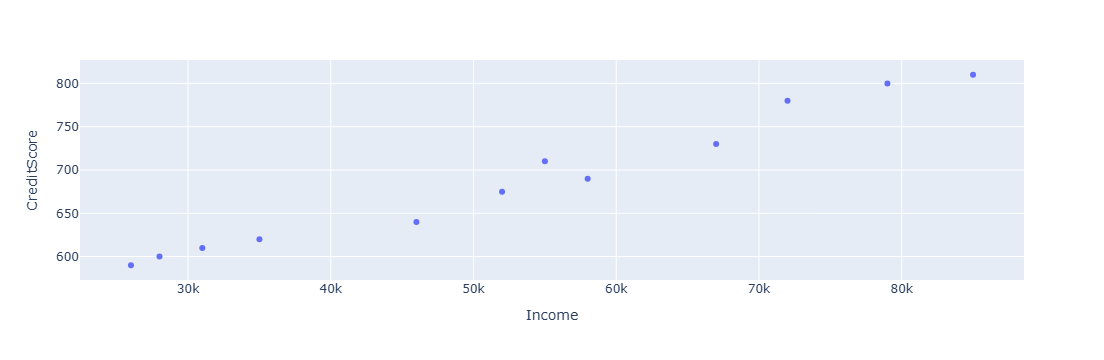

In [4]:
fig = px.scatter(df, x="Income",y="CreditScore")
fig.show()

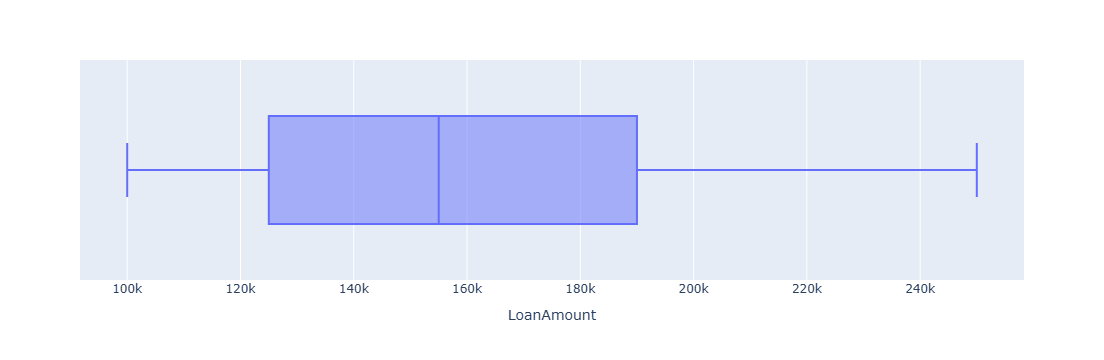

In [5]:
fig = px.box(df,x="LoanAmount")
fig.show()

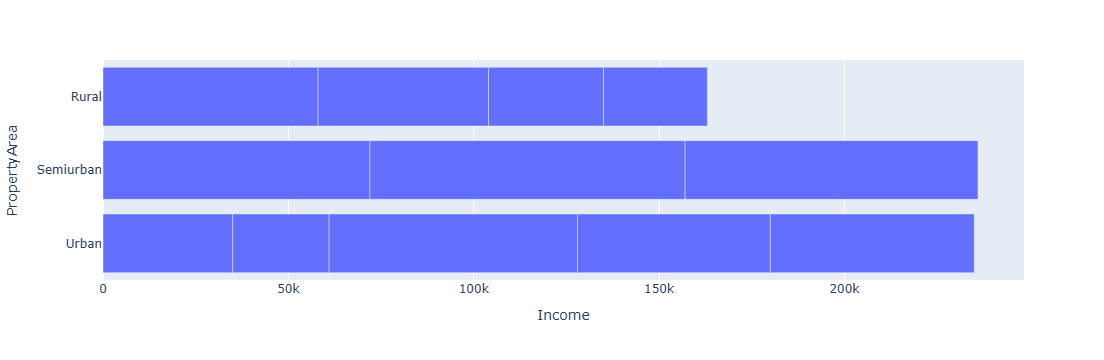

In [6]:
fig = px.bar(df, x="Income", y="PropertyArea")
fig.show()

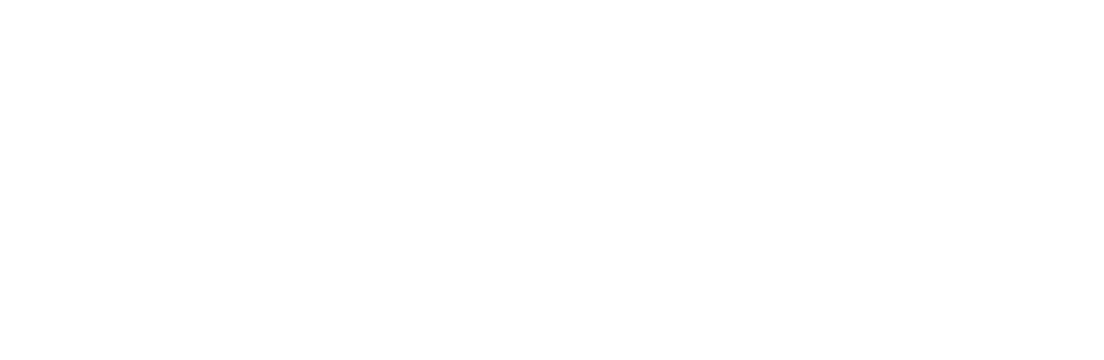

In [7]:
dfnames = df["LoanApproved"].unique()
dfnames = list(dfnames)
dfv1 = df[df["LoanApproved"]=="Yes"].shape[0]
dfv2 = df[df["LoanApproved"]=="No"].shape[0]

fig = px.pie(df)
fig.show()

In [46]:
x = df.drop(columns="LoanApproved",axis=1)
y = df["LoanApproved"]
x = pd.get_dummies(x)

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [55]:

model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
pre = model.predict(x_test)
print("Accuracy : ",accuracy_score(y_test,pre))
print("Confusion Matrix : ",confusion_matrix(y_test,pre))
print("F1 Score : ",recall_score(y_test,pre,pos_label="Yes"))
print("Precision Score : ",precision_score(y_test,pre,pos_label="Yes"))
print("Recall Score : ",recall_score(y_test,pre,pos_label="Yes"))
knn = [accuracy_score(y_test,pre),precision_score(y_test,pre,pos_label="Yes"),recall_score(y_test,pre,pos_label="Yes"),recall_score(y_test,pre,pos_label="Yes")]
arrknn = np.array(knn)
print(arrknn)

Accuracy :  0.6666666666666666
Confusion Matrix :  [[1 0]
 [1 1]]
F1 Score :  0.5
Precision Score :  1.0
Recall Score :  0.5
[0.66666667 1.         0.5        0.5       ]


In [56]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x,y,test_size=0.2,random_state=42)
model1 = DecisionTreeClassifier(criterion="entropy",max_depth=3,random_state=42)
model1.fit(x_train1,y_train1)
pre1 = model1.predict(x_test1)
print("Accuracy : ",accuracy_score(y_test1,pre1))
print("Confusion Matrix : ",confusion_matrix(y_test1,pre1))
print("F1 Score : ",f1_score(y_test1,pre1,pos_label="Yes"))
print("Precision Score : ",precision_score(y_test1,pre1,pos_label="Yes"))
print("Recall Score : ",recall_score(y_test1,pre1,pos_label="Yes"))
dt = [accuracy_score(y_test1,pre1),precision_score(y_test1,pre1,pos_label="Yes"),recall_score(y_test1,pre1,pos_label="Yes"),recall_score(y_test1,pre1,pos_label="Yes")]
arrdt = np.array(dt)
print(arrdt)

Accuracy :  1.0
Confusion Matrix :  [[1 0]
 [0 2]]
F1 Score :  1.0
Precision Score :  1.0
Recall Score :  1.0
[1. 1. 1. 1.]


In [79]:
dfarr = np.array([arrknn,arrdt])
dfclass = pd.DataFrame(dfarr,columns=["Accuracy","Precision","Recall","F1 Score"],index=["KNN","Decision Tree"])
dfclass

,Accuracy,Precision,Recall,F1 Score
KNN,0.666667,1.0,0.5,0.5
Decision Tree,1.000000,1.0,1.0,1.0
